In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn import tree

In [2]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(df[data.feature_names], df['target'], random_state=0)


In [4]:

clf = DecisionTreeClassifier(max_depth = 2,
                             random_state = 0)

In [5]:
clf.fit(X_train, Y_train)


DecisionTreeClassifier(max_depth=2, random_state=0)

In [6]:
clf.predict(X_test.iloc[0].values.reshape(1, -1))


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([2])

In [7]:
clf.predict(X_test[0:10])


array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1])

In [8]:
score = clf.score(X_test, Y_test)
print(score)

0.8947368421052632


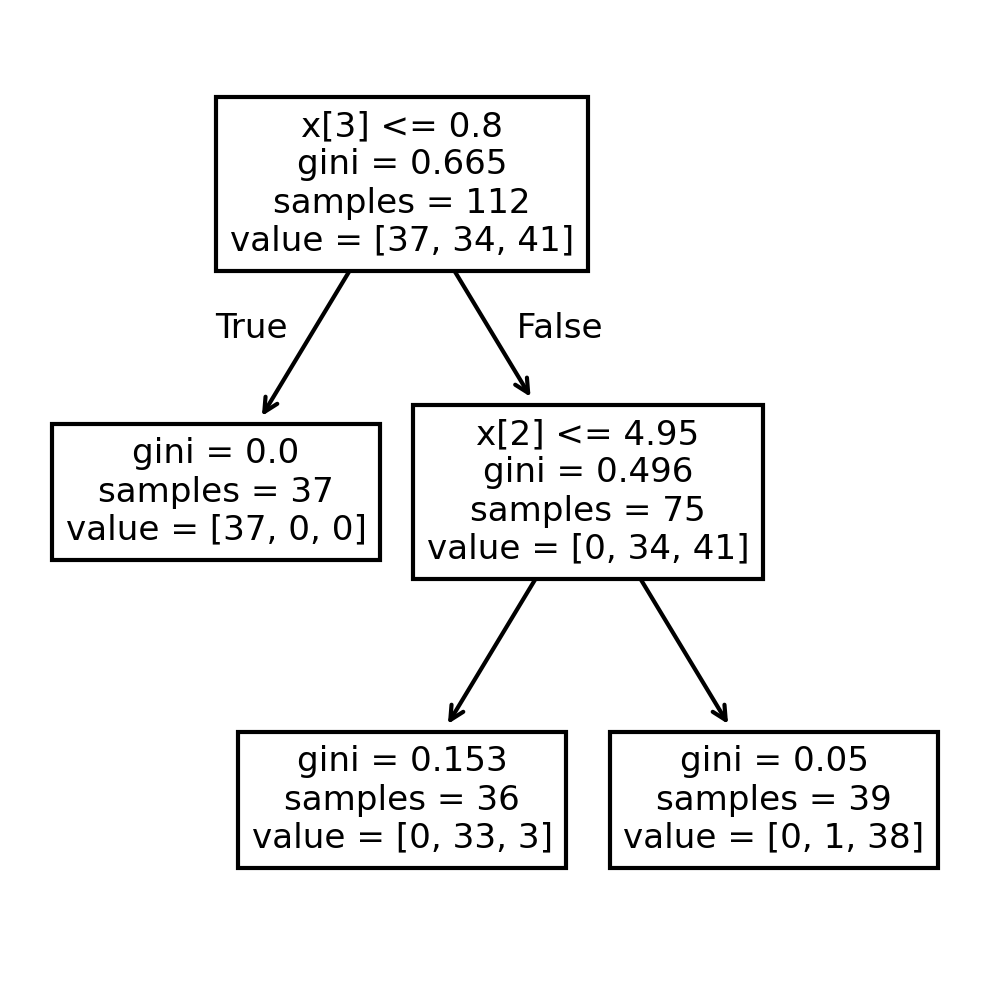

In [11]:
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (4,4), dpi = 300)

tree.plot_tree(clf);

In [12]:
fn = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
cn = ['setosa', 'versicolor', 'virginica']

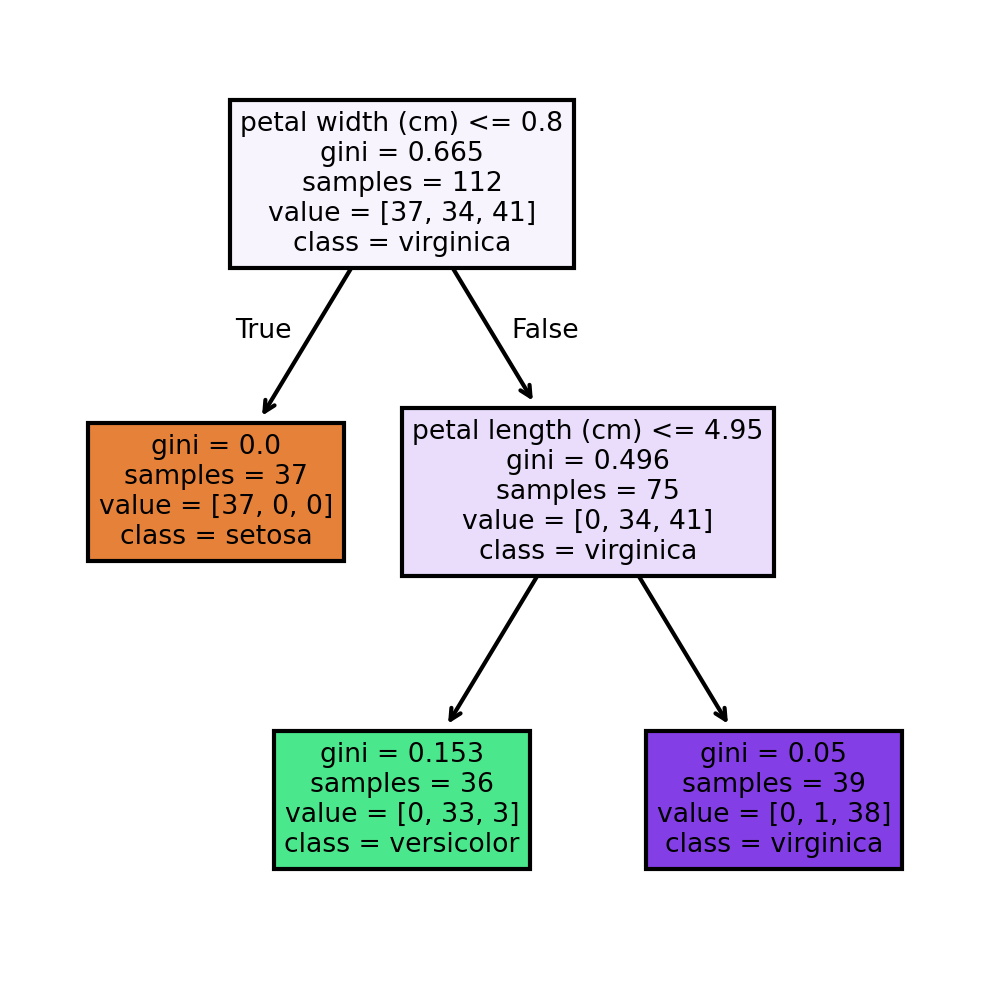

In [13]:
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (4,4), dpi = 300)

tree.plot_tree(clf,
               feature_names = fn,
               class_names=cn,
               filled = True);

In [14]:

tree.export_graphviz(clf,
                     out_file="tree.dot",
                     feature_names = fn,
                     class_names=cn,
                     filled = True)

In [15]:
!dot -Tpng -Gdpi=300 tree.dot -o tree.png


In [16]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [17]:
X = df.loc[:, df.columns != 'target']


In [18]:
y = df.loc[:, 'target'].values


In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, random_state=0)


In [20]:
rf = RandomForestClassifier(n_estimators=100,
                            random_state=0)

In [21]:
rf.fit(X_train, Y_train)


RandomForestClassifier(random_state=0)

In [22]:
score = rf.score(X_test, Y_test)
print(score)

0.972027972027972


In [23]:
data.target_names


array(['malignant', 'benign'], dtype='<U9')

In [24]:
rf.estimators_



[DecisionTreeClassifier(max_features='sqrt', random_state=209652396),
 DecisionTreeClassifier(max_features='sqrt', random_state=398764591),
 DecisionTreeClassifier(max_features='sqrt', random_state=924231285),
 DecisionTreeClassifier(max_features='sqrt', random_state=1478610112),
 DecisionTreeClassifier(max_features='sqrt', random_state=441365315),
 DecisionTreeClassifier(max_features='sqrt', random_state=1537364731),
 DecisionTreeClassifier(max_features='sqrt', random_state=192771779),
 DecisionTreeClassifier(max_features='sqrt', random_state=1491434855),
 DecisionTreeClassifier(max_features='sqrt', random_state=1819583497),
 DecisionTreeClassifier(max_features='sqrt', random_state=530702035),
 DecisionTreeClassifier(max_features='sqrt', random_state=626610453),
 DecisionTreeClassifier(max_features='sqrt', random_state=1650906866),
 DecisionTreeClassifier(max_features='sqrt', random_state=1879422756),
 DecisionTreeClassifier(max_features='sqrt', random_state=1277901399),
 DecisionTree

In [25]:
print(len(rf.estimators_))

100


In [26]:
rf.estimators_[0]


DecisionTreeClassifier(max_features='sqrt', random_state=209652396)

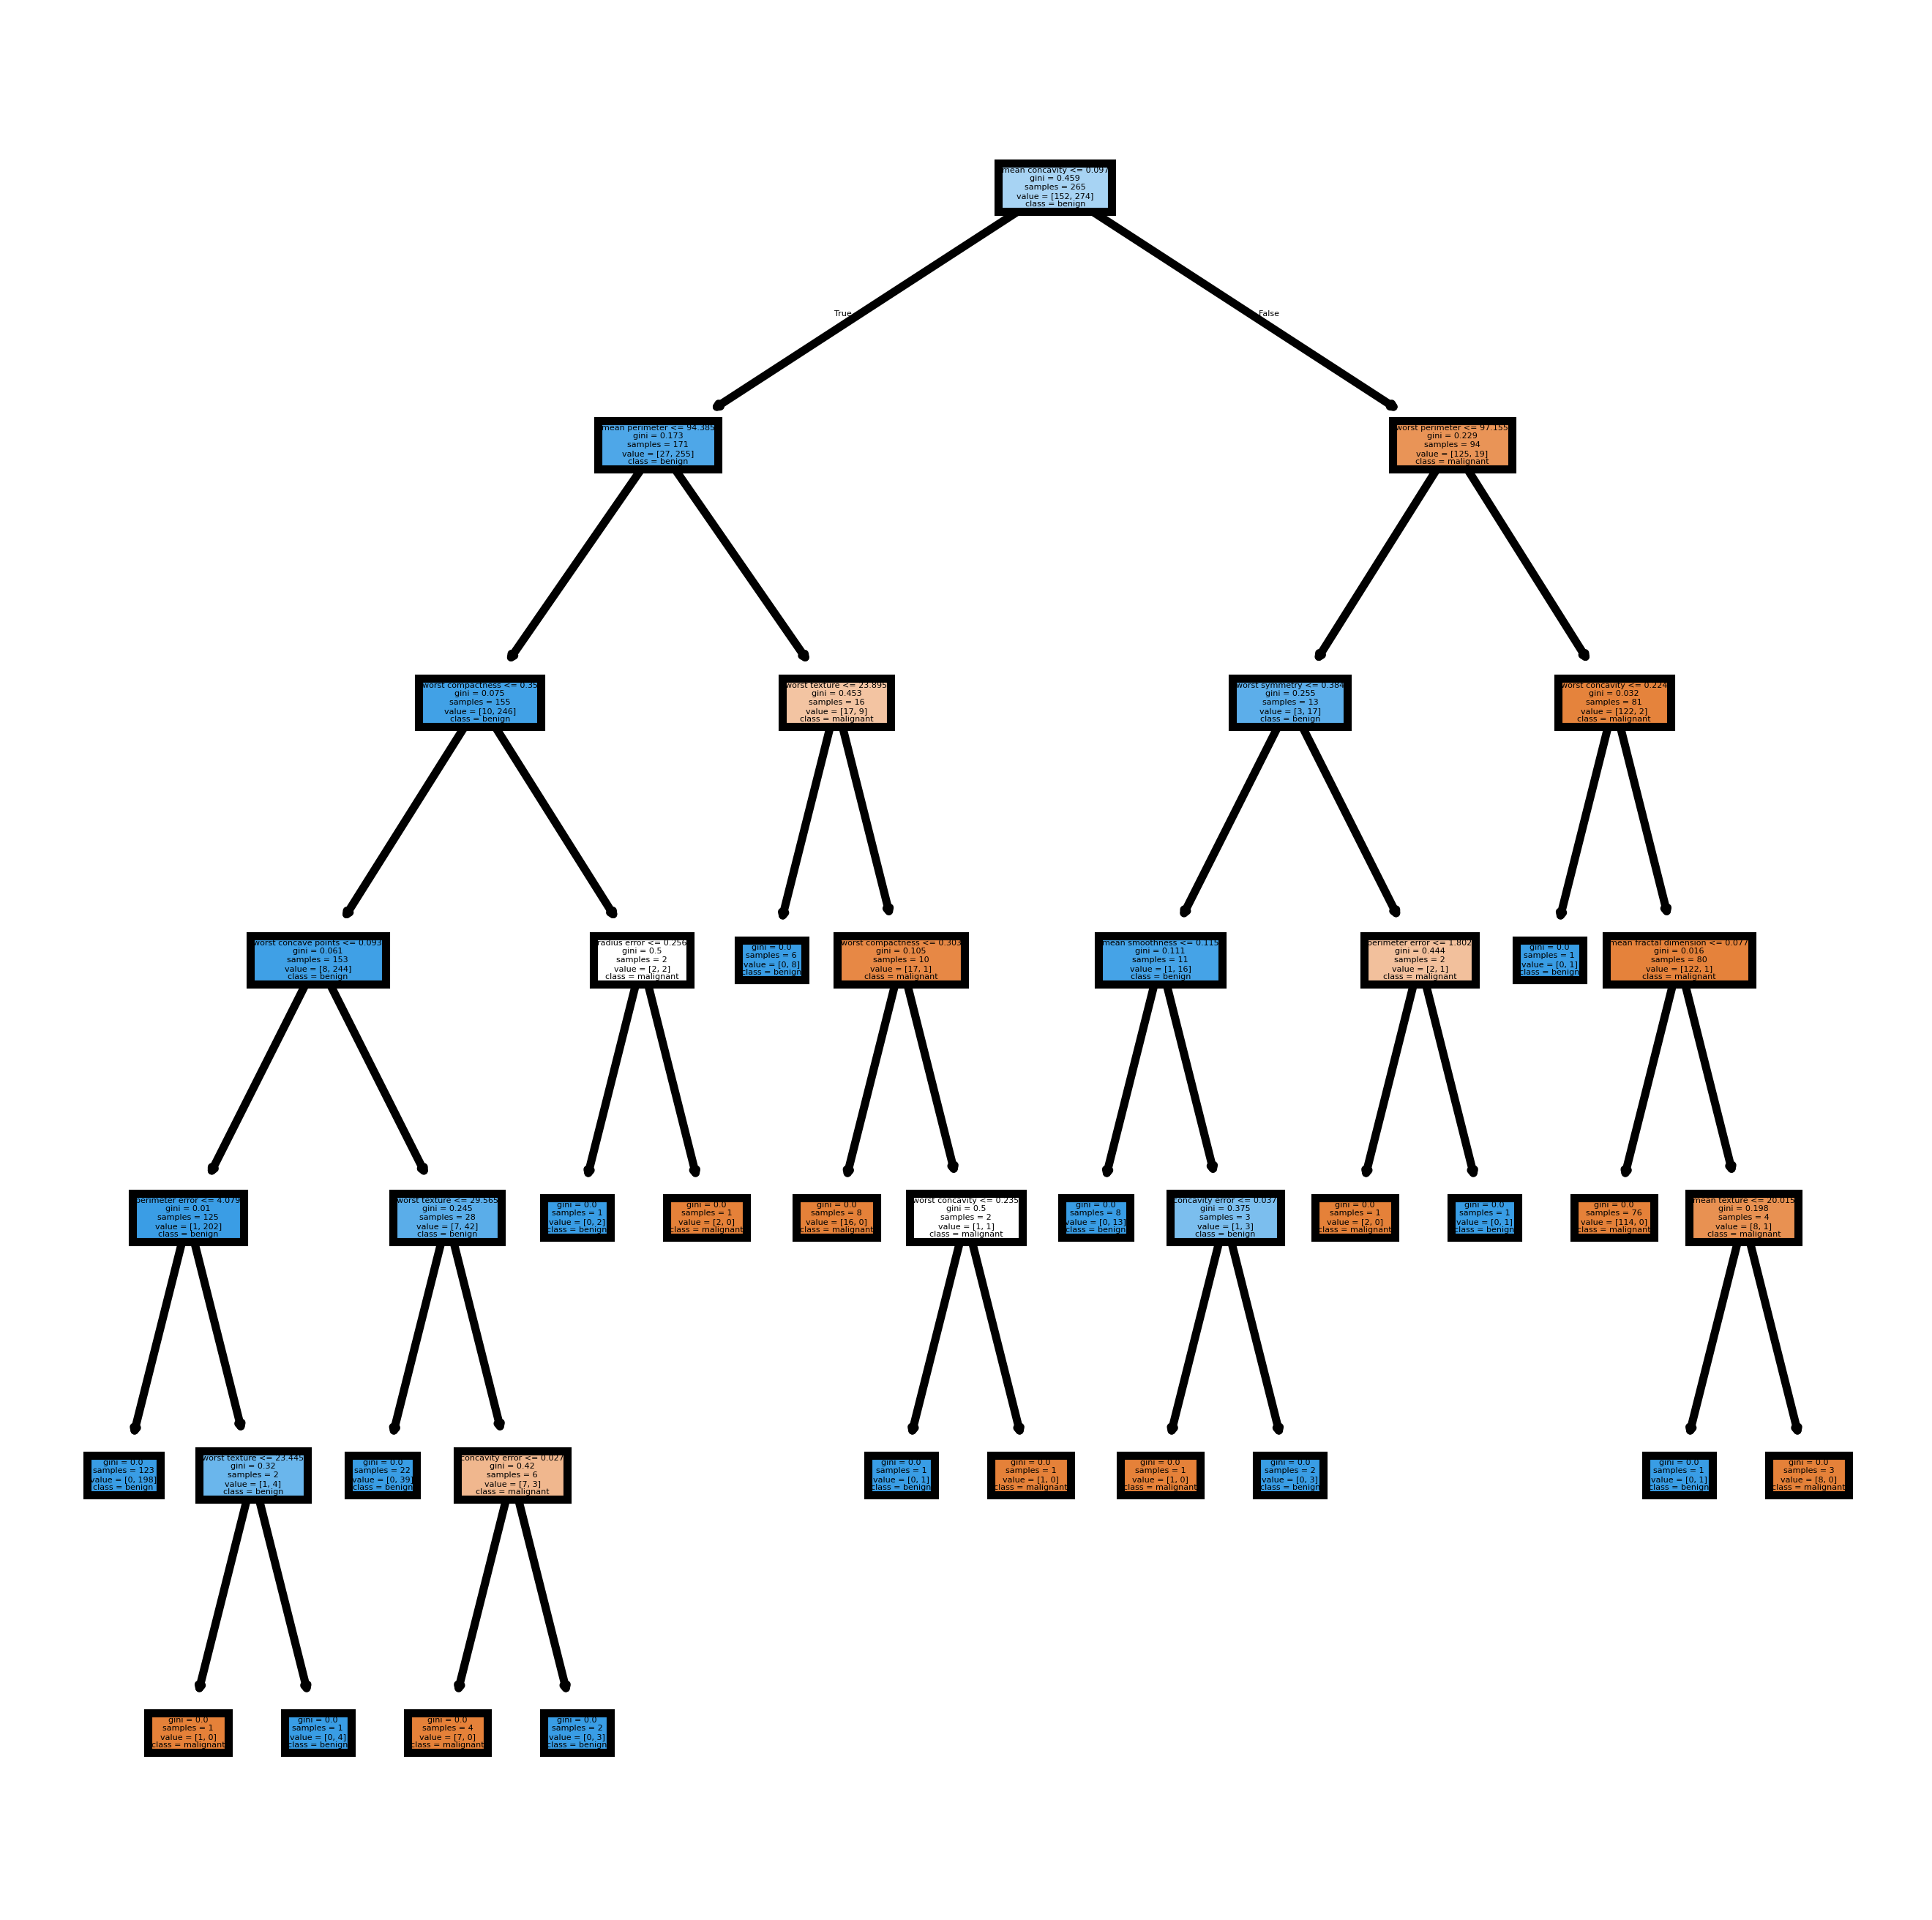

In [27]:
fn=data.feature_names
cn=data.target_names
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
tree.plot_tree(rf.estimators_[0],
               feature_names = fn,
               class_names=cn,
               filled = True);


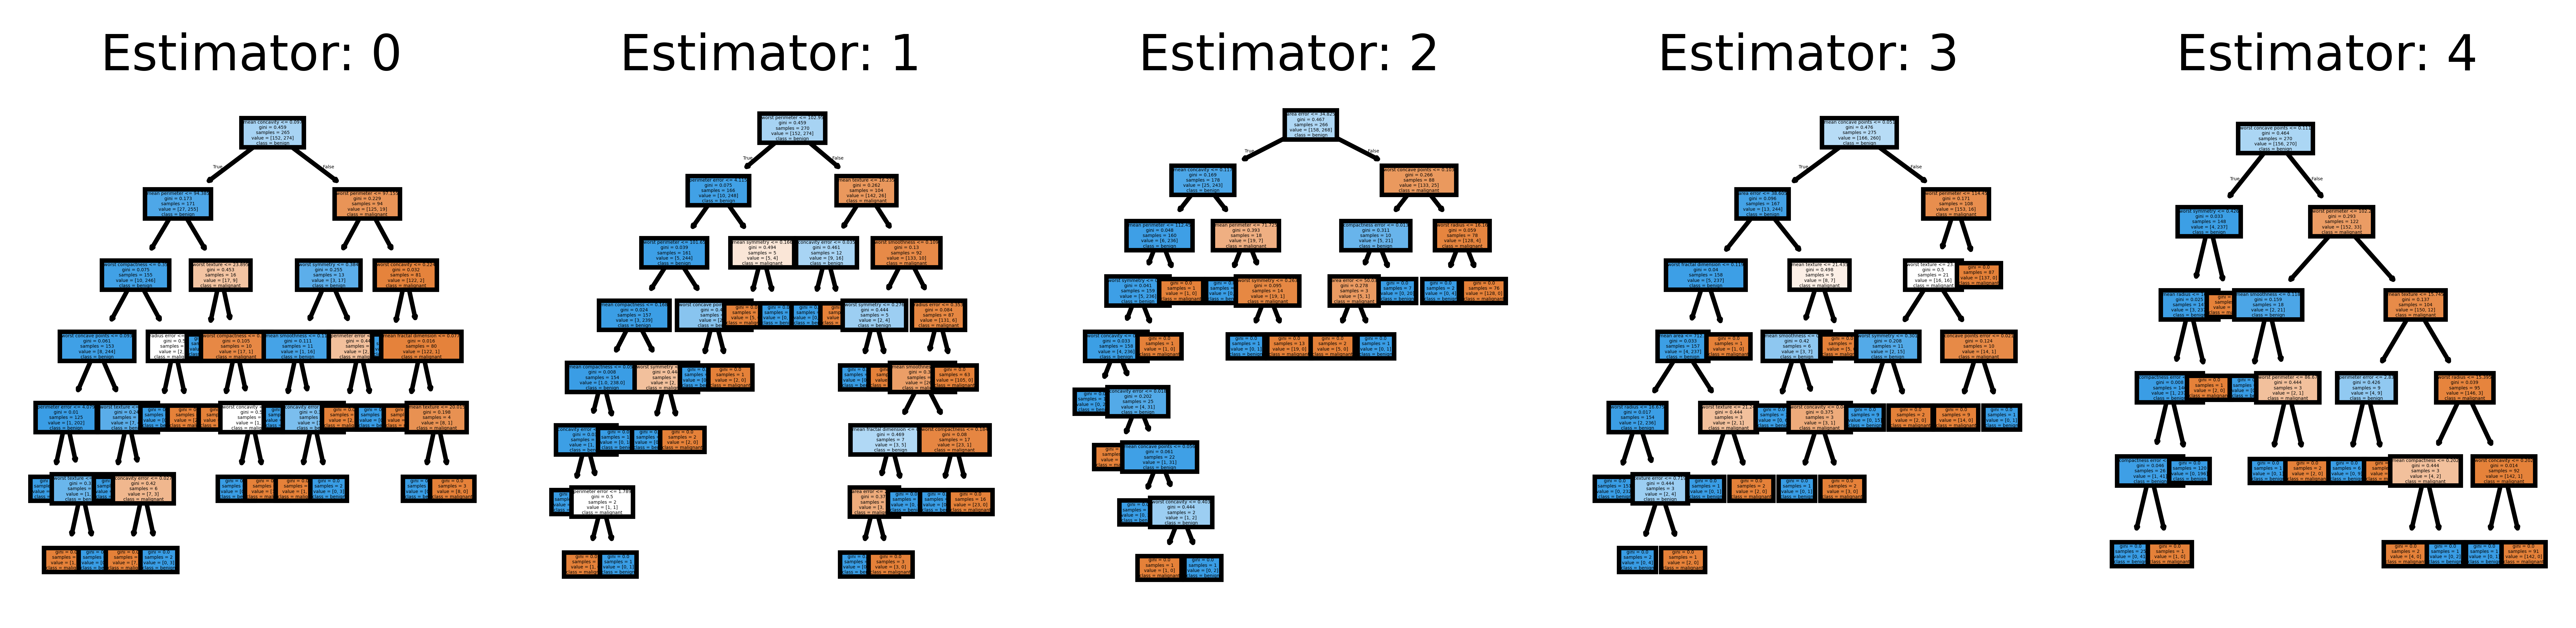

In [28]:

fn=data.feature_names
cn=data.target_names
fig, axes = plt.subplots(nrows = 1,ncols = 5,figsize = (10,2), dpi=1000)

for index in range(0, 5):
    tree.plot_tree(rf.estimators_[index],
                   feature_names = fn,
                   class_names=cn,
                   filled = True,
                   ax = axes[index]);

    axes[index].set_title('Estimator: ' + str(index), fontsize = 11)




In [29]:
fn = []
for feature in data.feature_names:
    parts = []
    for part in feature.split():
        parts.append(part.title())
    ''.join(parts)
    fn.append(''.join(parts))

cn=data.target_names

for index in range(0, len(rf.estimators_)):
    fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (4,4), dpi = 900)
    tree.plot_tree(rf.estimators_[index],
                   feature_names = fn,
                   class_names=cn,
                   filled = True)

    importances = pd.DataFrame({'feature':fn,'importance':np.round(rf.estimators_[index].feature_importances_,2)})
    importances = importances.sort_values('importance',ascending=False)

    axes.set_title('Estimator: ' + str(index) +
              '\n\'Most Important\' Feature:' + importances.iloc[0]['feature'] +
              '(' + str(importances.iloc[0]['importance']) +  ')', fontsize = 10.5)


    plt.close('all')